## RandomForestClassifier

In [1]:
# Load Files
import joblib
import numpy as np
from pathlib import Path

output_dir = Path("processed_outputs")

X_train = joblib.load(output_dir / "X_train_supervised.pkl")
y_train = joblib.load(output_dir / "y_train_supervised.pkl")
X_val   = joblib.load(output_dir / "X_val_supervised.pkl")
y_val   = joblib.load(output_dir / "y_val_supervised.pkl")
X_test  = joblib.load(output_dir / "X_test_supervised.pkl")
y_test  = joblib.load(output_dir / "y_test_supervised.pkl")
le              = joblib.load(output_dir / "label_encoder_supervised.pkl")
class_weight_dict = joblib.load(output_dir / "class_weights_supervised.pkl")

print("Files loaded successfully")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {list(le.classes_)}")

Files loaded successfully
X_train : (689284, 37)
X_val   : (139123, 37)
X_test  : (139123, 37)
Classes : ['Bot', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTPTest', 'DoS-Slowloris', 'FTP-BruteForce', 'PortScan', 'SSH-BruteForce', 'Web-Attack']


In [2]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=class_weight_dict,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   32.3s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:  1.3min finished


RandomForestClassifier(class_weight={0: 0.6748093396642029,
                                     1: 0.32831020866972455,
                                     2: 1.9069440602002987,
                                     3: 0.4631755780589583,
                                     4: 4.595226666666667, 5: 6.440702672397682,
                                     6: 4.595226666666667,
                                     7: 1.0857259868317424,
                                     8: 1.0130719146371934, 9: 3.44642},
                       max_depth=40, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400, n_jobs=-1, random_state=42, verbose=1)

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_val_pred = rf_model.predict(X_val)

print("Validation Results:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=le.classes_,
    digits=4
))

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s


Validation Results:
                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000     21888
            DDoS     0.9957    0.9919    0.9938     44990
   DoS-GoldenEye     0.9598    0.9743    0.9670      7746
        DoS-Hulk     0.9976    0.9966    0.9971     31889
DoS-SlowHTTPTest     0.9823    0.9823    0.9823       792
   DoS-Slowloris     0.9978    0.9983    0.9980      2293
  FTP-BruteForce     0.9911    0.9944    0.9928       898
        PortScan     0.9998    0.9993    0.9996     13604
  SSH-BruteForce     1.0000    0.9998    0.9999     14579
      Web-Attack     0.8131    0.9797    0.8887       444

        accuracy                         0.9949    139123
       macro avg     0.9737    0.9917    0.9819    139123
    weighted avg     0.9950    0.9949    0.9949    139123



[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.8s finished


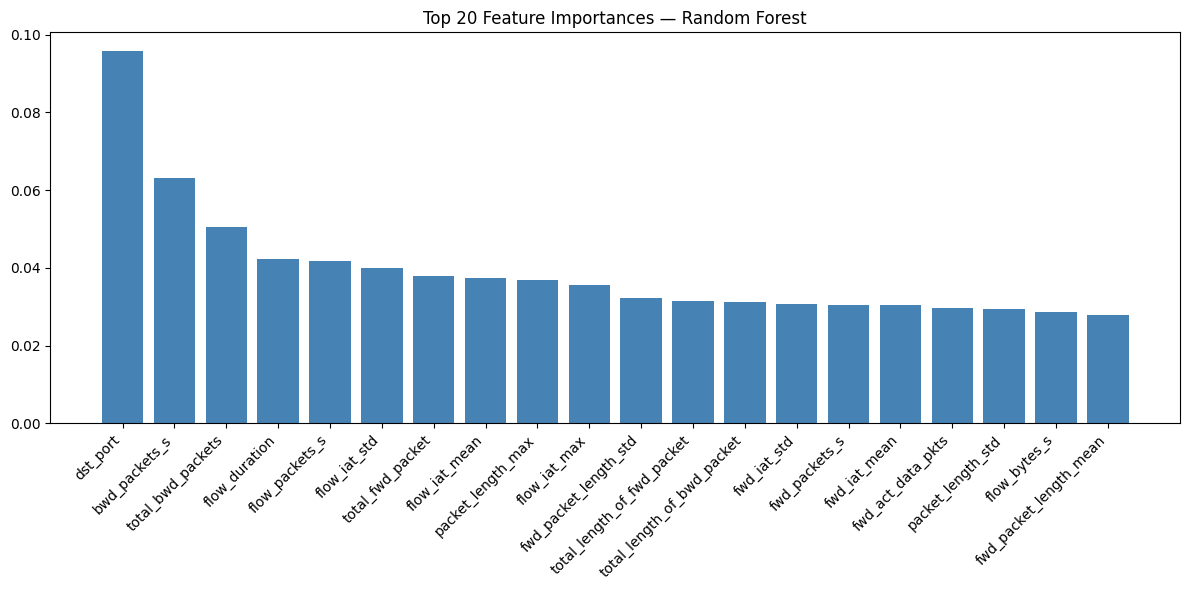

In [4]:
feature_names = joblib.load(output_dir / "scaler_supervised.pkl").feature_names_in_ \
    if hasattr(joblib.load(output_dir / "scaler_supervised.pkl"), 'feature_names_in_') \
    else [f"feature_{i}" for i in range(X_train.shape[1])]

importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[sorted_idx], color='steelblue')
plt.xticks(range(20), [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.title("Top 20 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.8s finished


Test Set Results:
                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000     21888
            DDoS     0.9959    0.9925    0.9942     44989
   DoS-GoldenEye     0.9617    0.9769    0.9693      7745
        DoS-Hulk     0.9983    0.9963    0.9973     31890
DoS-SlowHTTPTest     0.9836    0.9811    0.9823       793
   DoS-Slowloris     0.9970    0.9991    0.9980      2294
  FTP-BruteForce     0.9911    0.9889    0.9900       897
        PortScan     0.9999    0.9990    0.9995     13604
  SSH-BruteForce     1.0000    0.9999    0.9999     14580
      Web-Attack     0.7956    0.9842    0.8799       443

        accuracy                         0.9951    139123
       macro avg     0.9723    0.9918    0.9810    139123
    weighted avg     0.9953    0.9951    0.9952    139123



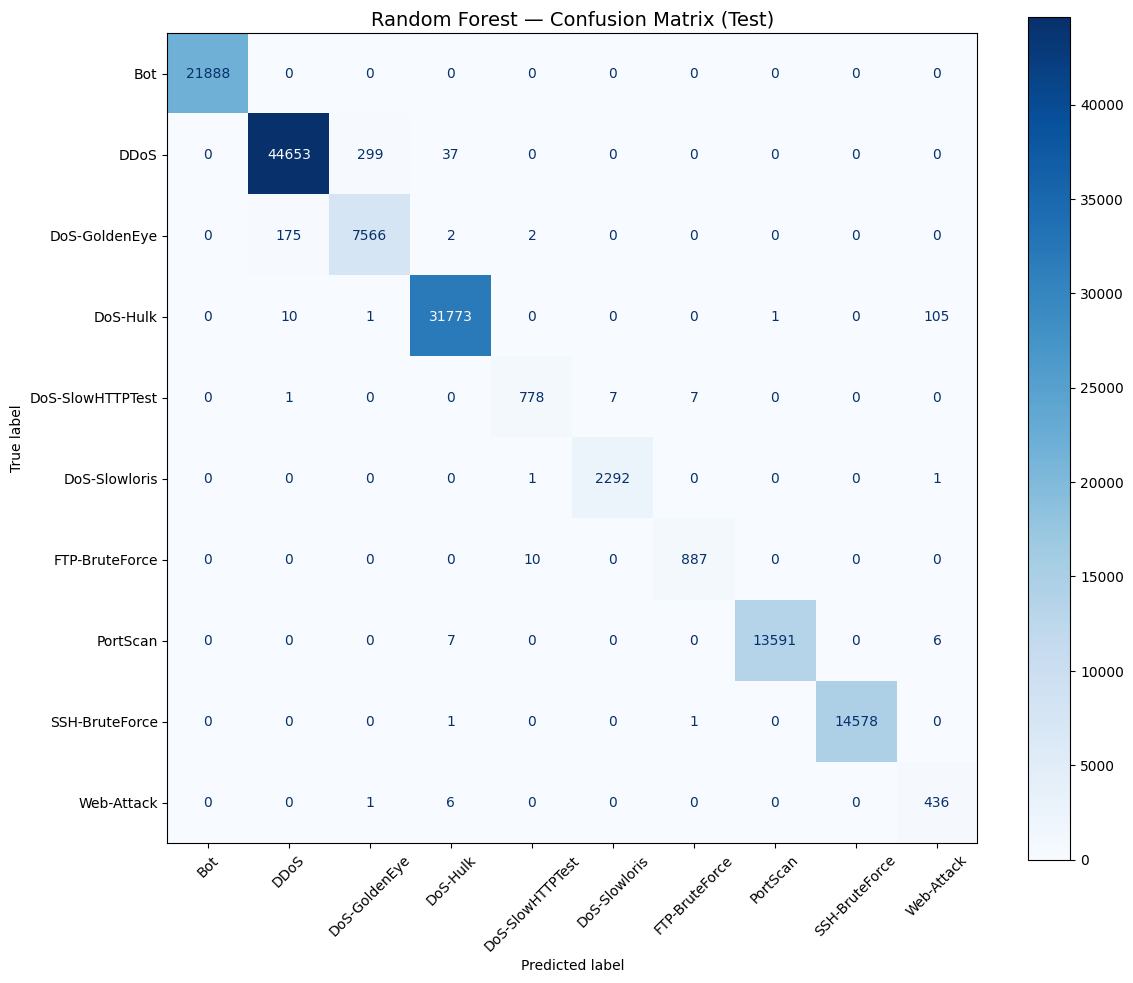

In [5]:
y_test_pred = rf_model.predict(X_test)

print("Test Set Results:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_,
    digits=4
))

cm_test = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=le.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title("Random Forest — Confusion Matrix (Test)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score
)

results = {
    "Accuracy"         : accuracy_score(y_test, y_test_pred),
    "Macro F1"         : f1_score(y_test, y_test_pred, average='macro'),
    "Macro Precision"  : precision_score(y_test, y_test_pred, average='macro'),
    "Macro Recall"     : recall_score(y_test, y_test_pred, average='macro'),
    "Weighted F1"      : f1_score(y_test, y_test_pred, average='weighted'),
}

print("Final Test Metrics:")
for metric, value in results.items():
    print(f"  {metric:<20} {value:.4f}")

Final Test Metrics:
  Accuracy             0.9951
  Macro F1             0.9810
  Macro Precision      0.9723
  Macro Recall         0.9918
  Weighted F1          0.9952


In [7]:
from sklearn.metrics import f1_score, accuracy_score

y_train_pred = rf_model.predict(X_train)
y_val_pred   = rf_model.predict(X_val)
y_test_pred  = rf_model.predict(X_test)

print("Overfitting Check — Score Comparison:")
print(f"{'Split':<10} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 45)
for name, y_true, y_pred in [
    ("Train", y_train, y_train_pred),
    ("Val",   y_val,   y_val_pred),
    ("Test",  y_test,  y_test_pred),
]:
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    wf1  = f1_score(y_true, y_pred, average='weighted')
    print(f"{name:<10} {acc:>10.4f} {mf1:>10.4f} {wf1:>12.4f}")

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    2.2s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    5.2s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.9s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.9s finished


Overfitting Check — Score Comparison:
Split        Accuracy   Macro F1  Weighted F1
---------------------------------------------
Train          0.9967     0.9954       0.9968
Val            0.9949     0.9819       0.9949
Test           0.9951     0.9810       0.9952


In [8]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test, y_test_pred,
    target_names=le.classes_,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).T.iloc[:-3]
report_df = report_df.sort_values('recall', ascending=True)

print("Per-Class Metrics (sorted by Recall):")
print(report_df[['precision', 'recall', 'f1-score', 'support']].to_string())

Per-Class Metrics (sorted by Recall):
                  precision    recall  f1-score  support
DoS-GoldenEye      0.961739  0.976888  0.969254   7745.0
DoS-SlowHTTPTest   0.983565  0.981084  0.982323    793.0
Web-Attack         0.795620  0.984199  0.879919    443.0
FTP-BruteForce     0.991061  0.988852  0.989955    897.0
DDoS               0.995852  0.992532  0.994189  44989.0
DoS-Hulk           0.998335  0.996331  0.997332  31890.0
PortScan           0.999926  0.999044  0.999485  13604.0
DoS-Slowloris      0.996955  0.999128  0.998040   2294.0
SSH-BruteForce     1.000000  0.999863  0.999931  14580.0
Bot                1.000000  1.000000  1.000000  21888.0


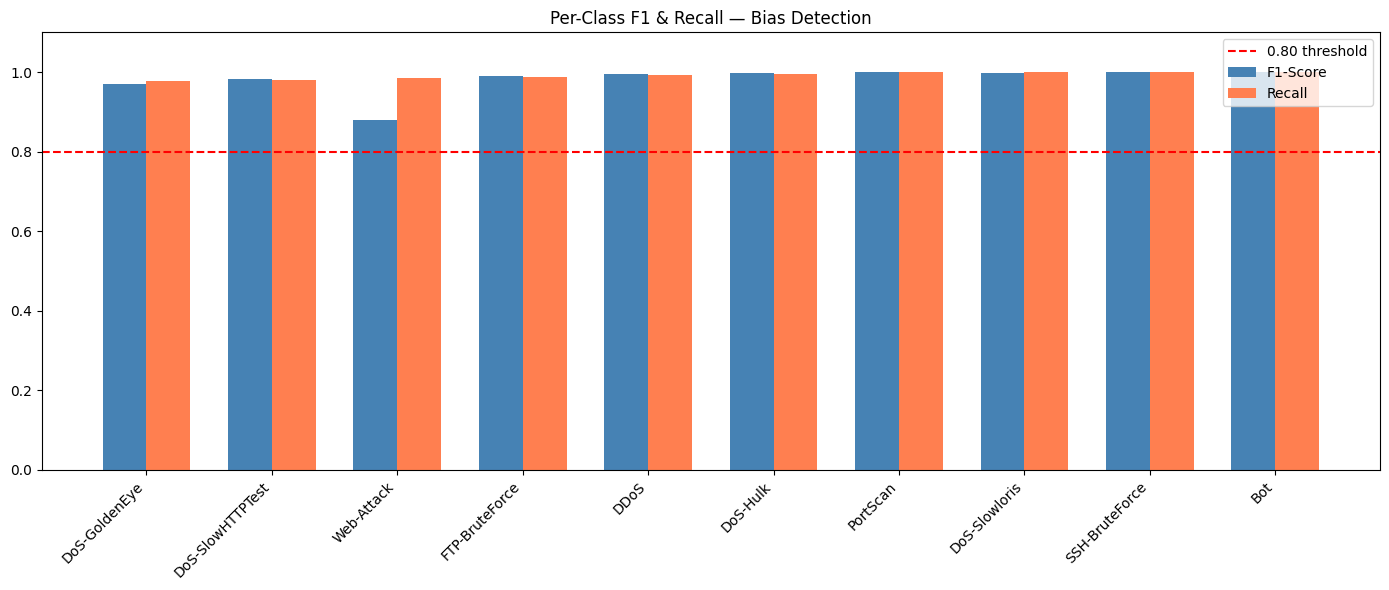

In [9]:
import matplotlib.pyplot as plt
import numpy as np

classes   = list(report_df.index)
f1_scores = list(report_df['f1-score'])
recalls   = list(report_df['recall'])

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='steelblue')
ax.bar(x + width/2, recalls,   width, label='Recall',   color='coral')
ax.axhline(y=0.80, color='red', linestyle='--', label='0.80 threshold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title("Per-Class F1 & Recall — Bias Detection")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import joblib
import os

project_root = os.path.abspath(os.path.join(os.getcwd()))
models_path  = os.path.join(project_root, "Models")
os.makedirs(models_path, exist_ok=True)

# Save Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_val   = rf_model.predict(X_val)
y_pred_test  = rf_model.predict(X_test)

joblib.dump(y_pred_train, os.path.join(models_path, "rf_preds_train.pkl"))
joblib.dump(y_pred_val,   os.path.join(models_path, "rf_preds_val.pkl"))
joblib.dump(y_pred_test,  os.path.join(models_path, "rf_preds_test.pkl"))

# Save Model
joblib.dump(rf_model, os.path.join(models_path, "rf_model.pkl"))

# Save Probability Scores (equivalent to decision_function in iso_forest)
train_scores = rf_model.predict_proba(X_train)
val_scores   = rf_model.predict_proba(X_val)
test_scores  = rf_model.predict_proba(X_test)

joblib.dump(train_scores, os.path.join(models_path, "rf_train_scores.pkl"))
joblib.dump(val_scores,   os.path.join(models_path, "rf_val_scores.pkl"))
joblib.dump(test_scores,  os.path.join(models_path, "rf_test_scores.pkl"))

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    2.5s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    5.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.8s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.8s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Do

['c:\\Users\\user\\Desktop\\AI_Cybersecurity\\Models\\rf_test_scores.pkl']